# Group analysis of columns data

## Load data

In [23]:
import os

### This is to analyse the data in group
import numpy as np
import pandas as pd
from numexpr.necompiler import default_type

# Import columns data
csv_dir = r'/Volumes/newJetStor/newJetStor/paros/paros_WORK/hanwen/ad_decode_test/output/'
subject_list = r'/Volumes/newJetStor/newJetStor/paros/paros_WORK/hanwen/ad_decode_test/code/subjects_valid.txt'
subject_group = r'/Users/bass/Desktop/HanwenLin/AD_DECODE_data3.xlsx'

# Read subject_list to get the subjects indexes
subjects = []
with open(subject_list, 'r') as f:
    for line in f:
        line = line.strip('\n')
        subjects.append(line)

print(subjects)

# Read subject_group to get subjects groups
ad_decode_data2 = pd.read_excel(subject_group, sheet_name='AD_DECODE_data2')
print('Size of the group data:', ad_decode_data2.shape)
print('Columns of the group data:', ad_decode_data2.columns)

type = 'fa'

['S04493', 'S03847', 'S02227', 'S02451', 'S02812', 'S02686', 'S03010', 'S02877', 'S00775', 'S02802', 'S02842', 'S03867', 'S02695', 'S01470', 'S02421', 'S03350', 'S02373', 'S03896', 'S02967', 'S02654', 'S02390', 'S02231', 'S03033', 'S02506', 'S03378', 'S02320', 'S02446', 'S02410', 'S02954', 'S02524', 'S01619', 'S02469', 'S02361', 'S03265', 'S02110', 'S02715', 'S03391', 'S03890', 'S02898', 'S03293', 'S02939', 'S02289', 'S04526', 'S04738', 'S02535', 'S02473', 'S02817', 'S03069', 'S03321', 'S02871', 'S02402', 'S02813', 'S02737', 'S02491', 'S02424', 'S03308', 'S02938', 'S02670', 'S03045', 'S02386', 'S02840', 'S02690', 'S03889', 'S02771', 'S02781', 'S02666', 'S03028', 'S02720', 'S03034', 'S01912', 'S03017', 'S02266', 'S02363', 'S02765', 'S01621', 'S03225', 'S03343', 'S02804', 'S02753', 'S02224', 'S02926', 'S02987', 'S02485', 'S01412']
Size of the group data: (123, 47)
Columns of the group data: Index(['Subject', 'MRI_Exam', 'age', 'genotype', 'sex', 'Risk', 'risk_for_ad',
       'ethnicity',

In [24]:
# Classified as left and right, risk 0 1 and 2 3, plot individual and averaged curves
# 4 categories in total
import matplotlib.pyplot as plt
import os

region_list = ['bankssts',
'caudalanteriorcingulate',
'caudalmiddlefrontal',
'cuneus',
'entorhinal',
'fusiform',
'inferiorparietal',
'inferiortemporal',
'isthmuscingulate',
'lateraloccipital',
'lateralorbitofrontal',
'lingual',
'medialorbitofrontal',
'middletemporal',
'parahippocampal',
'paracentral',
'parsopercularis',
'parsorbitalis',
'parstriangularis',
'pericalcarine',
'postcentral',
'posteriorcingulate',
'precentral',
'precuneus',
'rostralanteriorcingulate',
'rostralmiddlefrontal',
'superiorfrontal',
'superiorparietal',
'superiortemporal',
'supramarginal',
'frontalpole',
'temporalpole',
'transversetemporal',
'insula'
]
zero_risk_sub = ad_decode_data2[ad_decode_data2['risk_for_ad'] == 0]['MRI_Exam'].tolist()
one_risk_sub = ad_decode_data2[ad_decode_data2['risk_for_ad'] == 1]['MRI_Exam'].tolist()
two_risk_sub = ad_decode_data2[ad_decode_data2['risk_for_ad'] == 2]['MRI_Exam'].tolist()
three_risk_sub = ad_decode_data2[ad_decode_data2['risk_for_ad'] == 3]['MRI_Exam'].tolist()
low_risk_sub = zero_risk_sub + one_risk_sub
high_risk_sub = two_risk_sub + three_risk_sub
print(len(low_risk_sub))
print(len(high_risk_sub))


83
11


In [25]:
left_low_dic = {region: np.empty([1, 21]) for region in region_list}
right_low_dic = {region: np.empty([1, 21]) for region in region_list}
rl_low_dic = {region: np.empty([1, 21]) for region in region_list}
left_high_dic = {region: np.empty([1, 21]) for region in region_list}
right_high_dic = {region: np.empty([1, 21]) for region in region_list}
rl_high_dic = {region: np.empty([1, 21]) for region in region_list}

def get_subject_id(s):
    integer = int(s)
    expected_length = 5
    length = len(str(integer))
    s_id = 'S'
    for i in range(expected_length - length):
        s_id = s_id + '0'
    s_id = s_id + str(integer)
    return s_id

for subject in high_risk_sub:
    subject_id = get_subject_id(subject)
    for region in region_list:
        lh_region_name = subject_id + '_lh_' + region + '_' + type + '.csv'
        rh_region_name = subject_id + '_rh_' + region + '_' + type + '.csv'
        rl_region_name = subject_id + '_rl_' + region + '_' + type + '.csv'
        lh_csv = csv_dir + subject_id + '/columns_1mm/'+ lh_region_name
        rh_csv = csv_dir + subject_id + '/columns_1mm/'+ rh_region_name
        rl_csv = csv_dir + subject_id + '/columns_1mm/'+ rl_region_name
        if not os.path.exists(lh_csv):
            continue
        with open(lh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            left_high_dic[region] = np.append(left_high_dic[region], column.to_numpy(), axis=0)
        with open(rh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            right_high_dic[region] = np.append(right_high_dic[region], column.to_numpy(), axis=0)
        with open(rl_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            rl_high_dic[region] = np.append(rl_high_dic[region], column.to_numpy(), axis=0)

for subject in low_risk_sub:
    subject_id = get_subject_id(subject)
    for region in region_list:
        lh_region_name = subject_id + '_lh_' + region + '_' + type + '.csv'
        rh_region_name = subject_id + '_rh_' + region + '_' + type + '.csv'
        rl_region_name = subject_id + '_rl_' + region + '_' + type + '.csv'
        lh_csv = csv_dir + subject_id + '/columns_1mm/'+ lh_region_name
        rh_csv = csv_dir + subject_id + '/columns_1mm/'+ rh_region_name
        rl_csv = csv_dir + subject_id + '/columns_1mm/'+ rl_region_name
        # Check if file exit
        if not os.path.exists(lh_csv):
            continue
        with open(lh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            # Check if column contains NaN
            if column.isna().any().any():
                continue
            left_low_dic[region] = np.append(left_low_dic[region], column.to_numpy(), axis=0)
        with open(rh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            # Check if column contains NaN
            if column.isna().any().any():
                continue
            right_low_dic[region] = np.append(right_low_dic[region], column.to_numpy(), axis=0)
        with open(rl_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            rl_low_dic[region] = np.append(rl_low_dic[region], column.to_numpy(), axis=0)

for subject in high_risk_sub:
    subject_id = get_subject_id(subject)
    for region in region_list:
        lh_region_name = subject_id + '_lh_' + region + '_' + type + '.csv'
        rh_region_name = subject_id + '_rh_' + region + '_' + type + '.csv'
        rl_region_name = subject_id + '_rl_' + region + '_' + type + '.csv'
        lh_csv = csv_dir + subject_id + '/columns_1mm/'+ lh_region_name
        rh_csv = csv_dir + subject_id + '/columns_1mm/'+ rh_region_name
        rl_csv = csv_dir + subject_id + '/columns_1mm/'+ rl_region_name
        if not os.path.exists(lh_csv):
            continue
        with open(lh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            left_high_dic[region] = np.append(left_high_dic[region], column.to_numpy(), axis=0)
        with open(rh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            right_high_dic[region] = np.append(right_high_dic[region], column.to_numpy(), axis=0)
        with open(rl_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            rl_high_dic[region] = np.append(rl_high_dic[region], column.to_numpy(), axis=0)

for region in region_list:
    left_low_dic[region] = left_low_dic[region][1:]
    right_low_dic[region] = right_low_dic[region][1:]
    rl_low_dic[region] = rl_low_dic[region][1:]
    left_high_dic[region] = left_high_dic[region][1:]
    right_high_dic[region] = right_high_dic[region][1:]
    rl_high_dic[region] = rl_high_dic[region][1:]

In [26]:
# Plot the columns
from matplotlib.lines import Line2D
for region in region_list:
    plt.figure()
    for i in range(left_low_dic[region].shape[0]):
        plt.plot(range(21), left_low_dic[region][i], color='b', linewidth=0.1)
    for i in range(right_low_dic[region].shape[0]):
        plt.plot(range(21), right_low_dic[region][i], color='r', linewidth=0.1)
    for i in range(left_high_dic[region].shape[0]):
        plt.plot(range(21), left_high_dic[region][i], color='g', linewidth=0.1)
    for i in range(right_high_dic[region].shape[0]):
        plt.plot(range(21), right_high_dic[region][i], color='c', linewidth=0.1)
    plt.plot(range(21), np.mean(left_low_dic[region], axis=0), color='b', linewidth=2)
    plt.plot(range(21), np.mean(right_low_dic[region], axis=0), color='r', linewidth=2)
    plt.plot(range(21), np.mean(left_high_dic[region], axis=0), color='g', linewidth=2)
    plt.plot(range(21), np.mean(right_high_dic[region], axis=0), color='c', linewidth=2)
    legend_elements = [Line2D([0], [0], color='b', linewidth=0.1, label='left_low_individual'),
                       Line2D([0], [0], color='r', linewidth=0.1, label='right_low_individual'),
                       Line2D([0], [0], color='g', linewidth=0.1, label='left_high_individual'),
                       Line2D([0], [0], color='c', linewidth=0.1, label='right_high_individual'),
                       Line2D([0], [0], color='b', linewidth=2, label='left_low_mean'),
                       Line2D([0], [0], color='r', linewidth=2, label='right_low_mean'),
                       Line2D([0], [0], color='g', linewidth=2, label='left_high_mean'),
                       Line2D([0], [0], color='c', linewidth=2, label='right_high_mean')]
    plt.legend(handles=legend_elements)
    plt.title(region)
    plt.xticks([0, 21], ['WM/GM','Pial'])
    plt.ylabel(type)
    fig_dir = r'/Volumes/newJetStor/newJetStor/paros/paros_WORK/hanwen/ad_decode_test/output/linear_model_analysis/'
    plt.savefig(fig_dir + type + '_' + region + '.png')
    plt.close()


In [27]:
# Linear Model
valid_subjects = []
left_dic = {region: np.empty([1, 3]) for region in region_list}
right_dic = {region: np.empty([1, 3]) for region in region_list}
for subject in subjects:
    subject_id = subject
    file_valid = 'True'
    for region in region_list:
        lh_region_name = subject_id + '_lh_' + region + '_' + type + '.csv'
        rh_region_name = subject_id + '_rh_' + region + '_' + type + '.csv'
        lh_csv = csv_dir + subject_id + '/columns_1mm/'+ lh_region_name
        rh_csv = csv_dir + subject_id + '/columns_1mm/'+ rh_region_name
        if not os.path.exists(lh_csv):
            file_valid = 'False'
            continue
        with open(lh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                file_valid = 'False'
                continue
            three_bin = column.to_numpy()
            three_bin = np.array([[np.mean(three_bin[0, 0:7]), np.mean(three_bin[0, 7:14]), np.mean(three_bin[0, 14:])]])
            left_dic[region] = np.append(left_dic[region], three_bin, axis=0)
        with open(rh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                file_valid = 'False'
                continue
            three_bin = column.to_numpy()
            three_bin = np.array([[np.mean(three_bin[0, 0:7]), np.mean(three_bin[0, 7:14]), np.mean(three_bin[0, 14:])]])
            right_dic[region] = np.append(right_dic[region], three_bin, axis=0)
    if file_valid == 'True':
        valid_subjects.append(subject_id)

In [28]:
valid_subject_index = []
for subject in valid_subjects:
    subject = subject[1:]
    subject_index = int(subject)
    valid_subject_index.append(subject_index)
for region in region_list:
    right_dic[region] = right_dic[region][1:]
    left_dic[region] = left_dic[region][1:]

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Construct X
X = np.empty([0,3])
age_column = np.empty([0,1])
genotype_column = np.empty([0,1])
sex_column = np.empty([0,1])
# Collect features: age, genotype and sex
for subject in valid_subject_index:
    age = ad_decode_data2[ad_decode_data2['MRI_Exam'] == subject]['age'].values[0]
    genotype = ad_decode_data2[ad_decode_data2['MRI_Exam'] == subject]['genotype'].values[0]
    sex = ad_decode_data2[ad_decode_data2['MRI_Exam'] == subject]['sex'].values[0]
    if '4' in genotype:
        genotype = 1
    else:
        genotype = 0
    if sex == 'M':
        sex = 1
    else:
        sex = 0
    age_column = np.append(age_column, age)
    genotype_column = np.append(genotype_column, genotype)
    sex_column = np.append(sex_column, sex)

age_column = age_column.reshape((-1, 1))
genotype_column = genotype_column.reshape((-1, 1))
sex_column = sex_column.reshape((-1, 1))
# Standard age
scaler = StandardScaler()
age_std = scaler.fit_transform(age_column)

# Standard genotype
mu_genotype = np.mean(genotype_column)
sigma_genotype = np.std(genotype_column)
genotype_std = (genotype_column - mu_genotype) / sigma_genotype

# Standard sex
mu_sex = np.mean(sex_column)
sigma_sex = np.std(sex_column)
sex_std = (sex_column - mu_sex) / sigma_sex

# Combine features
X = np.column_stack((age_std, genotype_std, sex_std))
print(X)

[[ 0.67825758 -0.93189112 -0.85539892]
 [-2.12139645  1.07308674  1.16904519]
 [-1.02286429 -0.93189112  1.16904519]
 [-0.36858664 -0.93189112 -0.85539892]
 [ 1.0053964  -0.93189112  1.16904519]
 [-0.56486994  1.07308674 -0.85539892]
 [ 0.92034031 -0.93189112 -0.85539892]
 [-1.80799746  1.07308674 -0.85539892]
 [-1.41543087  1.07308674 -0.85539892]
 [ 0.52515662 -0.93189112 -0.85539892]
 [ 0.08940771  1.07308674 -0.85539892]
 [-0.65516025 -0.93189112  1.16904519]
 [-0.76115323 -0.93189112 -0.85539892]
 [ 1.66817966  1.07308674 -0.85539892]
 [ 1.9213851  -0.93189112 -0.85539892]
 [ 0.22026323  1.07308674  1.16904519]
 [-0.49944217  1.07308674 -0.85539892]
 [-2.06970851 -0.93189112  1.16904519]
 [-1.41543087 -0.93189112 -0.85539892]
 [-0.95743652 -0.93189112 -0.85539892]
 [ 0.8359385   1.07308674 -0.85539892]
 [-1.41543087 -0.93189112  1.16904519]
 [-0.69572547  1.07308674 -0.85539892]
 [ 0.74368535 -0.93189112 -0.85539892]
 [ 0.93996864  1.07308674  1.16904519]
 [ 0.54740206 -0.93189112

lh_bankssts
lh_caudalanteriorcingulate
Weights:
[[ 0.02278859  0.00586544  0.00157813]
 [ 0.02041186  0.00599724 -0.0001463 ]
 [ 0.01505316  0.00563095  0.00040789]]
MSE:
0.0013986982566995304
R2:
0.2484971128855157
R2_for_single_bin:
0.17069733021521116
0.2733734819694804
0.30142052647185535


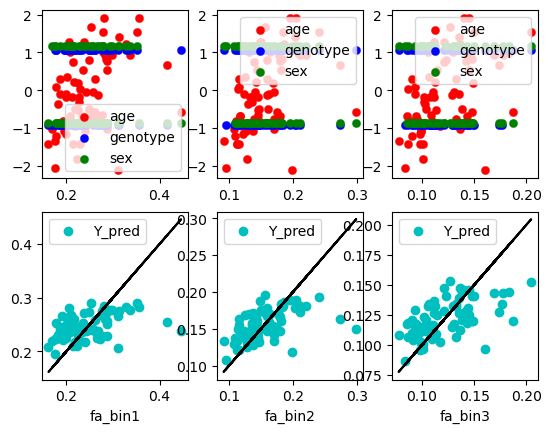

lh_caudalmiddlefrontal
Weights:
[[ 9.59648245e-03  3.56417636e-03 -7.46159182e-04]
 [ 1.21717516e-02  3.60224467e-03  3.96329553e-05]
 [ 9.29312045e-03  4.47573785e-03  2.21583753e-03]]
MSE:
0.0003740159740200009
R2:
0.2367132826650661
R2_for_single_bin:
0.1800649661173438
0.3006921505031628
0.22938273137469234


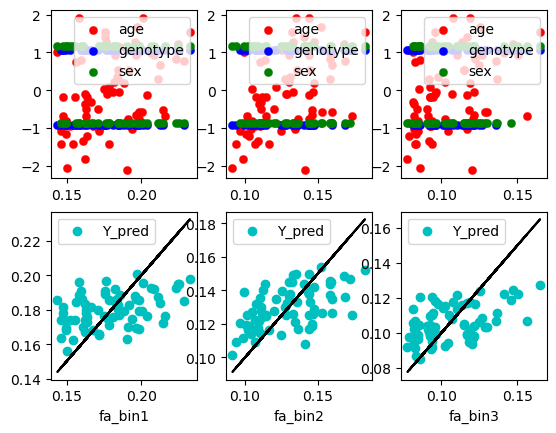

lh_cuneus
lh_entorhinal
lh_fusiform
lh_inferiorparietal
lh_inferiortemporal
lh_isthmuscingulate
lh_lateraloccipital
lh_lateralorbitofrontal
lh_lingual
lh_medialorbitofrontal
lh_middletemporal
lh_parahippocampal
lh_paracentral
lh_parsopercularis
Weights:
[[0.00764422 0.00262282 0.00124206]
 [0.012767   0.00361606 0.00214783]
 [0.00985897 0.0034282  0.00324353]]
MSE:
0.0005825543257866696
R2:
0.16170979598700397
R2_for_single_bin:
0.09078540857081618
0.2316410155607077
0.16270296382948812


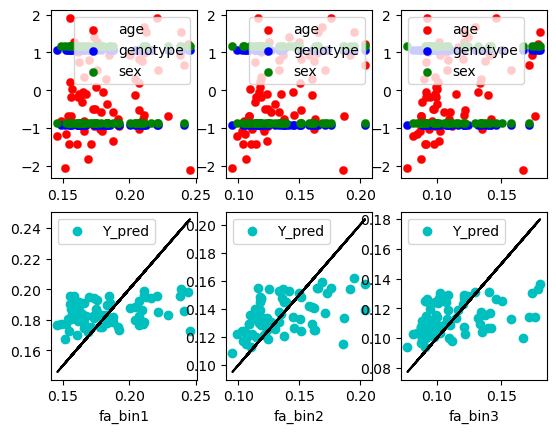

lh_parsorbitalis
lh_parstriangularis
lh_pericalcarine
lh_postcentral
Weights:
[[0.01518059 0.00221068 0.00129378]
 [0.01446107 0.00297214 0.00209645]
 [0.01020532 0.00357114 0.00126577]]
MSE:
0.0005025333668081641
R2:
0.2640537286495798
R2_for_single_bin:
0.26018582530723755
0.3253429936142994
0.20663236702720256


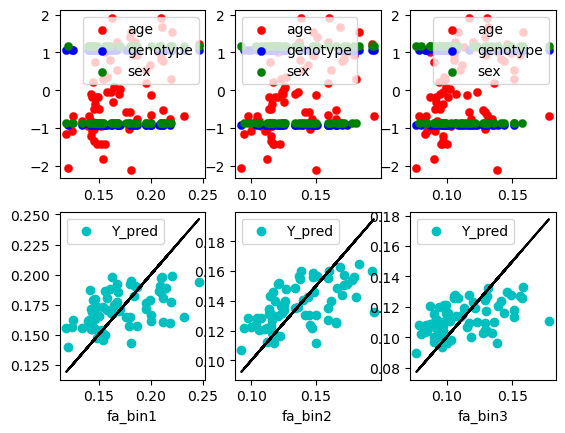

lh_posteriorcingulate
Weights:
[[ 0.02170169  0.00397016  0.00162297]
 [ 0.01936908  0.00427536 -0.00087599]
 [ 0.01287832  0.00475279 -0.00054543]]
MSE:
0.000627486871190599
R2:
0.3495591650830148
R2_for_single_bin:
0.32569531107557304
0.40709372924823684
0.31588845492523476


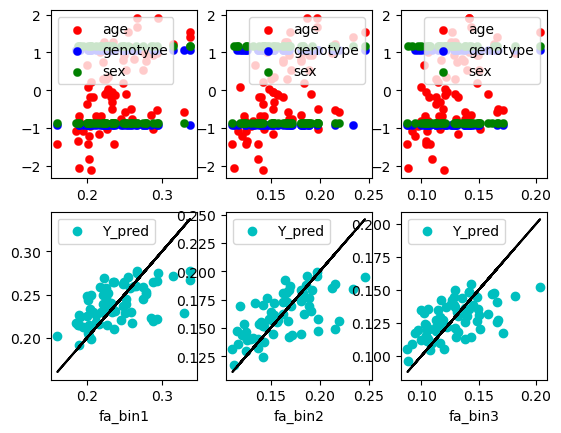

lh_precentral
Weights:
[[ 0.0126454   0.00328959 -0.00163369]
 [ 0.01469526  0.0036498  -0.00215356]
 [ 0.01083466  0.00449263 -0.00209289]]
MSE:
0.0004467908776795155
R2:
0.2754541201521134
R2_for_single_bin:
0.23783621839977198
0.3560436488597307
0.23248249319683745


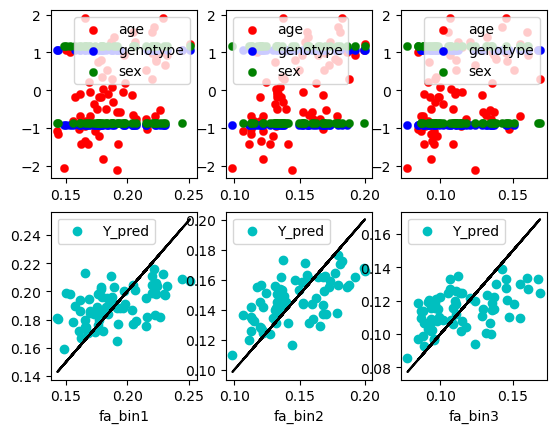

lh_precuneus
lh_rostralanteriorcingulate
lh_rostralmiddlefrontal
lh_superiorfrontal
Weights:
[[ 9.32818985e-03  2.66161922e-03  1.14849244e-03]
 [ 1.09254588e-02  2.90681769e-03 -1.28532053e-06]
 [ 7.55684939e-03  2.95127829e-03 -2.65968240e-04]]
MSE:
0.000469680992412086
R2:
0.1597100153978048
R2_for_single_bin:
0.1335658641911982
0.21092060989035732
0.13464357211185918


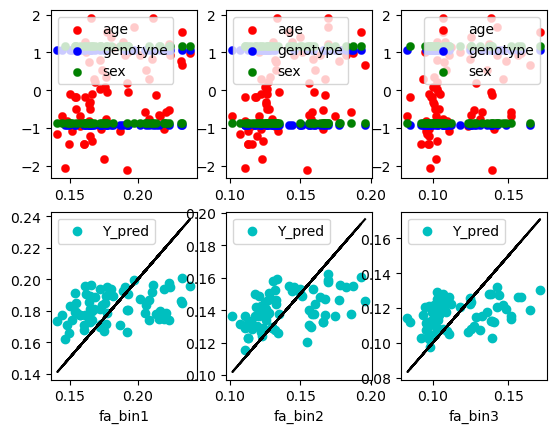

lh_superiorparietal
lh_superiortemporal
lh_supramarginal
lh_frontalpole
lh_temporalpole
lh_transversetemporal
Weights:
[[ 0.00845114  0.0006708   0.00022758]
 [ 0.01406875  0.0029364  -0.0003071 ]
 [ 0.00734278  0.00376632  0.00011659]]
MSE:
0.0006263150621666241
R2:
0.1434650189158739
R2_for_single_bin:
0.08677026802381438
0.23622424210751014
0.10740054661629628


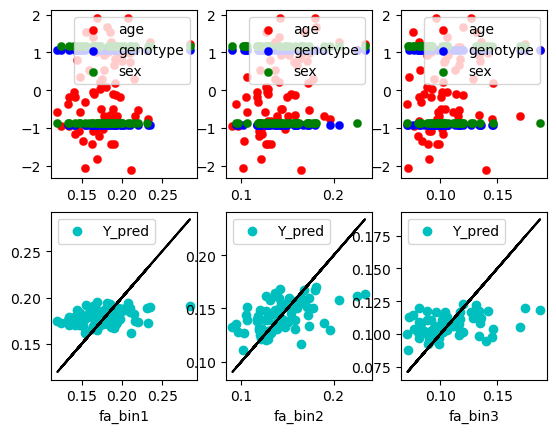

lh_insula


In [38]:
from sklearn.metrics import r2_score
# For left hemisphere
for region in region_list:
    print('lh_' + region)
    Y = left_dic[region]
    linear_model = LinearRegression()
    linear_model.fit(X, Y)
    r2 = linear_model.score(X, Y)
    weights = linear_model.coef_
    Y_pred = linear_model.predict(X)
    mse = np.mean((Y - Y_pred) ** 2)
    mse_1 = np.mean((Y_pred[:, 0] - Y[:, 0]) ** 2)
    mse_2 = np.mean((Y_pred[:, 1] - Y[:, 1]) ** 2)
    mse_3 = np.mean((Y_pred[:, 2] - Y[:, 2]) ** 2)
    r2_1 = 1 - mse_1 / np.mean((Y[:, 0] - np.mean(Y[:, 0])) ** 2)
    r2_2 = 1 - mse_2 / np.mean((Y[:, 1] - np.mean(Y[:, 1])) ** 2)
    r2_3 = 1 - mse_3 / np.mean((Y[:, 2] - np.mean(Y[:, 2])) ** 2)


    if r2_1 > 0.2 or r2_2 > 0.2 or r2_3 > 0.2:
        print('Weights:')
        print(weights)
        print('MSE:')
        print(mse)
        print('R2:')
        print(r2)
        print('R2_for_single_bin:')
        print(r2_1)
        print(r2_2)
        print(r2_3)
        plt.subplot(2, 3, 1)
        plt.scatter(Y[:,0], X[:,0], label='age', color='r', linewidths=0.2)
        plt.scatter(Y[:,0], X[:,1], label='genotype', color='b', linewidths=0.2)
        plt.scatter(Y[:,0], X[:,2], label='sex', color='g', linewidths=0.2)
        plt.legend()
        plt.subplot(2, 3, 4)
        plt.scatter(Y[:,0], Y_pred[:,0], label='Y_pred', color='c')
        plt.plot(Y[:,0], Y[:,0], color='k')
        plt.legend()
        plt.xlabel(type + '_bin1')
        plt.subplot(2, 3, 2)
        plt.scatter(Y[:,1], X[:,0], label='age', color='r', linewidths=0.2)
        plt.scatter(Y[:,1], X[:,1], label='genotype', color='b', linewidths=0.2)
        plt.scatter(Y[:,1], X[:,2], label='sex', color='g', linewidths=0.2)
        plt.legend()
        plt.subplot(2, 3, 5)
        plt.scatter(Y[:,1], Y_pred[:,1], label='Y_pred', color='c')
        plt.plot(Y[:,1], Y[:,1], color='k')
        plt.legend()
        plt.xlabel(type + '_bin2')
        plt.subplot(2, 3, 3)
        plt.scatter(Y[:,2], X[:,0], label='age', color='r', linewidths=0.2)
        plt.scatter(Y[:,2], X[:,1], label='genotype', color='b', linewidths=0.2)
        plt.scatter(Y[:,2], X[:,2], label='sex', color='g', linewidths=0.2)
        plt.legend()
        plt.subplot(2, 3, 6)
        plt.scatter(Y[:,2], Y_pred[:,2], label='Y_pred', color='c')
        plt.plot(Y[:,2], Y[:,2], color='k')
        plt.legend()
        plt.xlabel(type + '_bin3')
        plt.show()



In [41]:
# Construct X
X = np.empty([0,3])
age_column = np.empty([0,1])
# Collect features: age, genotype and sex
for subject in valid_subject_index:
    age = ad_decode_data2[ad_decode_data2['MRI_Exam'] == subject]['age'].values[0]
    age_column = np.append(age_column, age)

age_column = age_column.reshape((-1, 1))
# Standard age
scaler = StandardScaler()
age_std = scaler.fit_transform(age_column)

# Combine features
X = age_column
print(X)

[[63.        ]
 [20.21      ]
 [37.        ]
 [47.        ]
 [68.        ]
 [44.        ]
 [66.7       ]
 [25.        ]
 [31.        ]
 [60.66      ]
 [54.        ]
 [42.62      ]
 [41.        ]
 [78.13      ]
 [82.        ]
 [56.        ]
 [45.        ]
 [21.        ]
 [31.        ]
 [38.        ]
 [65.41      ]
 [31.        ]
 [42.        ]
 [64.        ]
 [67.        ]
 [61.        ]
 [36.92777778]
 [71.26      ]
 [40.        ]
 [44.        ]
 [76.        ]
 [81.65      ]
 [36.        ]
 [67.86      ]
 [72.        ]
 [44.78      ]
 [76.        ]
 [52.        ]
 [57.        ]
 [41.        ]
 [50.        ]
 [32.        ]
 [34.        ]
 [38.        ]
 [48.        ]
 [64.45      ]
 [53.        ]
 [65.        ]
 [45.        ]
 [42.        ]
 [51.        ]
 [58.        ]
 [50.88      ]
 [57.        ]
 [35.        ]
 [50.        ]
 [42.        ]
 [70.        ]
 [70.        ]
 [36.        ]
 [68.        ]
 [72.        ]
 [50.        ]
 [67.04      ]
 [69.        ]
 [52.        ]
 [69.     

lh_bankssts
lh_caudalanteriorcingulate
Weights:
[[0.00144241]] [[0.00128302]] [[0.00093648]]
MSE:
0.0025682860499554494 0.0011517529417021941 0.000577917543440125
R2:
0.15912564700188014 0.2503052362857515 0.2617179274304494


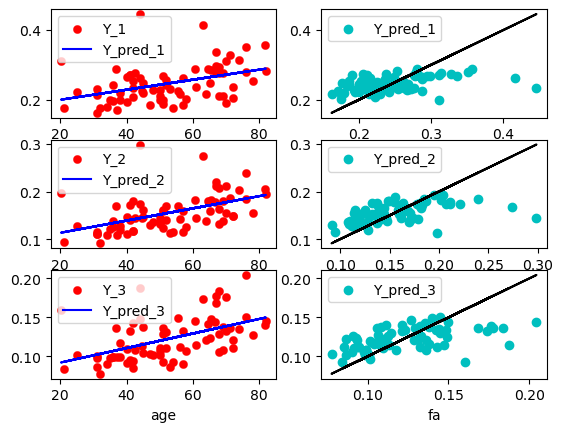

lh_caudalmiddlefrontal
Weights:
[[0.00059564]] [[0.00076505]] [[0.00057255]]
MSE:
0.0004512829353720316 0.00036032839974869973 0.0003600521542667004
R2:
0.15515805936659433 0.2750749429442121 0.17538260055641464


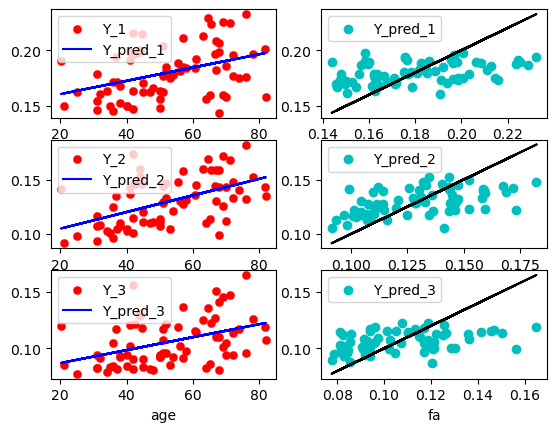

lh_cuneus
lh_entorhinal
lh_fusiform
lh_inferiorparietal
lh_inferiortemporal
lh_isthmuscingulate
lh_lateraloccipital
lh_lateralorbitofrontal
lh_lingual
lh_medialorbitofrontal
lh_middletemporal
lh_parahippocampal
lh_paracentral
lh_parsopercularis
Weights:
[[0.00047926]] [[0.00080722]] [[0.00062032]]
MSE:
0.000625143473754061 0.0005768508401966594 0.0005912343080714422
R2:
0.07904625641979657 0.20878071756977445 0.13197372739168278


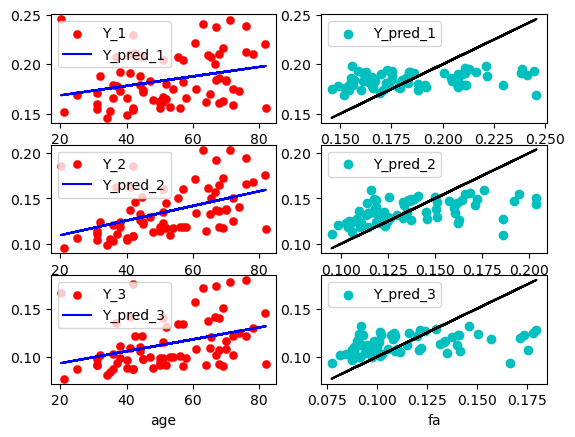

lh_parsorbitalis
lh_parstriangularis
lh_pericalcarine
lh_postcentral
Weights:
[[0.00097602]] [[0.00092359]] [[0.00063861]]
MSE:
0.0006565190740139947 0.0004514389969108961 0.0004319322491419601
R2:
0.25315189992452736 0.3062291854358258 0.18070362553677755


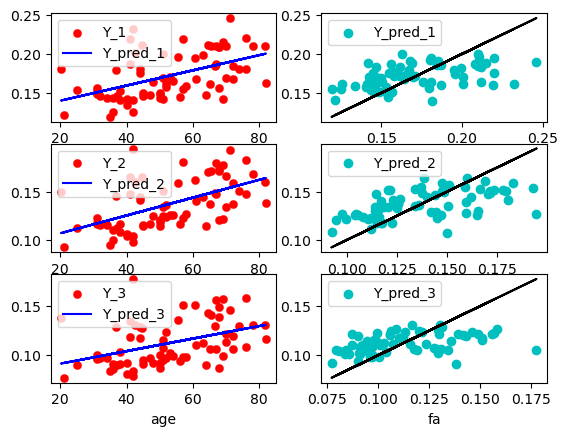

lh_posteriorcingulate
Weights:
[[0.00138788]] [[0.00122864]] [[0.00080033]]
MSE:
0.0009851989743922143 0.0005605124196627724 0.00039606103383671545
R2:
0.3135283686344884 0.38617546856718155 0.2742002440772794


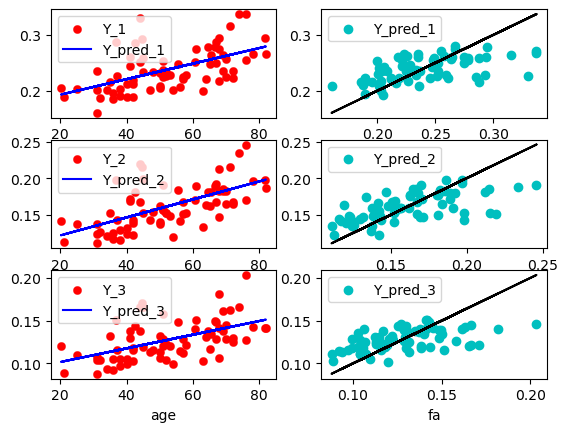

lh_precentral
Weights:
[[0.00079611]] [[0.00092627]] [[0.00066643]]
MSE:
0.0005326550708018066 0.0004145035940226752 0.0004507307275798876
R2:
0.21750149173784195 0.3259305739595221 0.18711145968144516


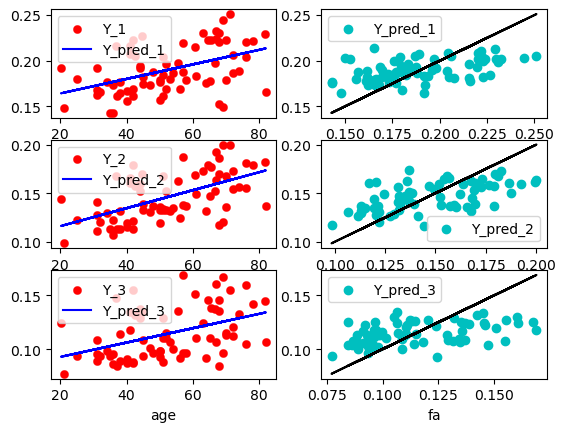

lh_precuneus
lh_rostralanteriorcingulate
lh_rostralmiddlefrontal
lh_superiorfrontal
lh_superiorparietal
lh_superiortemporal
lh_supramarginal
lh_frontalpole
lh_temporalpole
lh_transversetemporal
Weights:
[[0.00054746]] [[0.00089442]] [[0.00044779]]
MSE:
0.0007423697871495946 0.0006408651209548589 0.0005187465247555684
R2:
0.08618154708114889 0.22576772274818702 0.0828196436794374


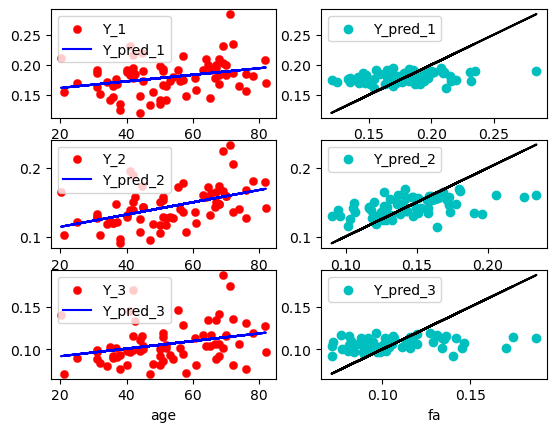

lh_insula


In [43]:
# For left hemisphere
for region in region_list:
    print('lh_' + region)
    Y_1 = left_dic[region][:,0].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_1)
    r2_1 = linear_model.score(X, Y_1)
    weights_1 = linear_model.coef_
    Y_pred_1 = linear_model.predict(X)
    mse_1 = np.mean((Y_pred_1 - Y_1) ** 2)

    Y_2 = left_dic[region][:,1].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_2)
    r2_2 = linear_model.score(X, Y_2)
    weights_2 = linear_model.coef_
    Y_pred_2 = linear_model.predict(X)
    mse_2 = np.mean((Y_pred_2 - Y_2) ** 2)

    Y_3 = left_dic[region][:,2].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_3)
    r2_3 = linear_model.score(X, Y_3)
    weights_3 = linear_model.coef_
    Y_pred_3 = linear_model.predict(X)
    mse_3 = np.mean((Y_pred_3 - Y_3) ** 2)

    if r2_1 > 0.2 or r2_2 > 0.2 or r2_3 > 0.2:
        print('Weights:')
        print(weights_1, weights_2, weights_3)
        print('MSE:')
        print(mse_1, mse_2, mse_3)
        print('R2:')
        print(r2_1, r2_2, r2_3)
        plt.subplot(3, 2, 1)
        plt.scatter(X[:,0], Y_1[:,0], label='Y_1', color='r', linewidths=0.2)
        plt.plot(X[:,0], Y_pred_1[:,0], label='Y_pred_1', color='b')
        plt.legend()
        plt.xlabel('age')
        plt.subplot(3, 2, 2)
        plt.scatter(Y_1[:,0], Y_pred_1[:,0], label='Y_pred_1', color='c')
        plt.plot(Y_1[:,0], Y_1[:,0], color='k')
        plt.legend()
        plt.xlabel(type)
        plt.subplot(3, 2, 3)
        plt.scatter(X[:,0], Y_2[:,0], label='Y_2', color='r', linewidths=0.2)
        plt.plot(X[:,0], Y_pred_2[:,0], label='Y_pred_2', color='b')
        plt.legend()
        plt.xlabel('age')
        plt.subplot(3, 2, 4)
        plt.scatter(Y_2[:,0], Y_pred_2[:,0], label='Y_pred_2', color='c')
        plt.plot(Y_2[:,0], Y_2[:,0], color='k')
        plt.legend()
        plt.xlabel(type)
        plt.subplot(3, 2, 5)
        plt.scatter(X[:,0], Y_3[:,0], label='Y_3', color='r', linewidths=0.2)
        plt.plot(X[:,0], Y_pred_3[:,0], label='Y_pred_3', color='b')
        plt.legend()
        plt.xlabel('age')
        plt.subplot(3, 2, 6)
        plt.scatter(Y_3[:,0], Y_pred_3[:,0], label='Y_pred_3', color='c')
        plt.plot(Y_3[:,0], Y_3[:,0], color='k')
        plt.legend()
        plt.xlabel(type)
        plt.show()


rh_bankssts
rh_caudalanteriorcingulate
Weights:
[[0.00147933]] [[0.00139659]] [[0.00112165]]
MSE:
0.0014826774417760482 0.0010491212871313906 0.0007585341299046097
R2:
0.25639180388724636 0.30279570315051774 0.27925169529446425


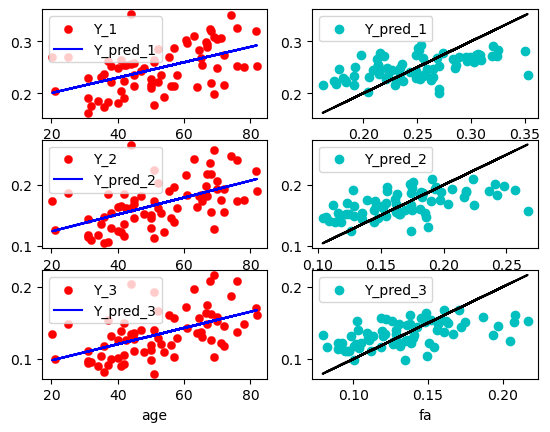

rh_caudalmiddlefrontal
Weights:
[[0.00069821]] [[0.0008344]] [[0.00052339]]
MSE:
0.00043720501687156244 0.00031066943431787226 0.00033189783167632904
R2:
0.2066471520891734 0.34362248751435176 0.1616395733717323


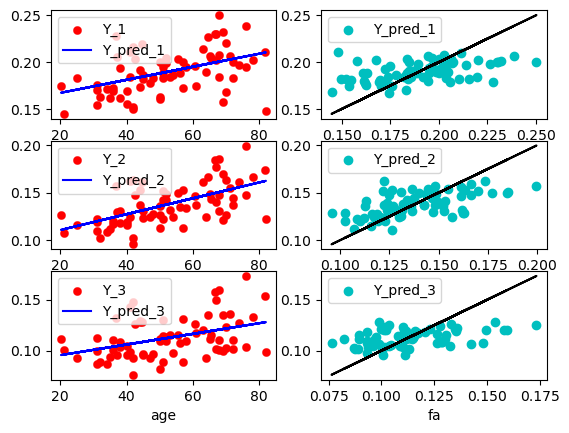

rh_cuneus
rh_entorhinal
rh_fusiform
rh_inferiorparietal
rh_inferiortemporal
rh_isthmuscingulate
rh_lateraloccipital
rh_lateralorbitofrontal
rh_lingual
rh_medialorbitofrontal
rh_middletemporal
rh_parahippocampal
rh_paracentral
rh_parsopercularis
rh_parsorbitalis
rh_parstriangularis
rh_pericalcarine
rh_postcentral
Weights:
[[0.0011538]] [[0.0011161]] [[0.00075651]]
MSE:
0.0005668784595686534 0.00037336826009327033 0.0003616832748878827
R2:
0.35425272819942 0.4380023802405375 0.2698795965394325


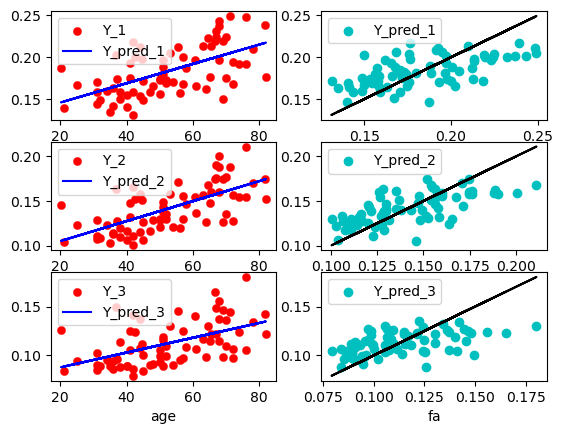

rh_posteriorcingulate
Weights:
[[0.00120386]] [[0.00105416]] [[0.00065051]]
MSE:
0.0009870892439327189 0.0006426990998182363 0.0004387899026910489
R2:
0.25538782916543656 0.28770218077293863 0.18386113440922258


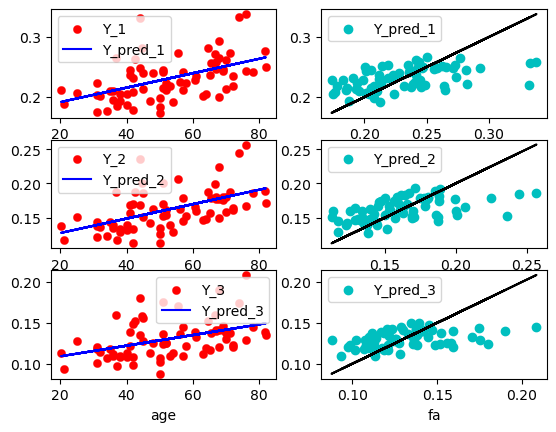

rh_precentral
Weights:
[[0.00087466]] [[0.00100446]] [[0.00065893]]
MSE:
0.00046552421754111873 0.0003568596702363147 0.0004024866970882273
R2:
0.27740206997078676 0.3977572530416702 0.20127689152976325


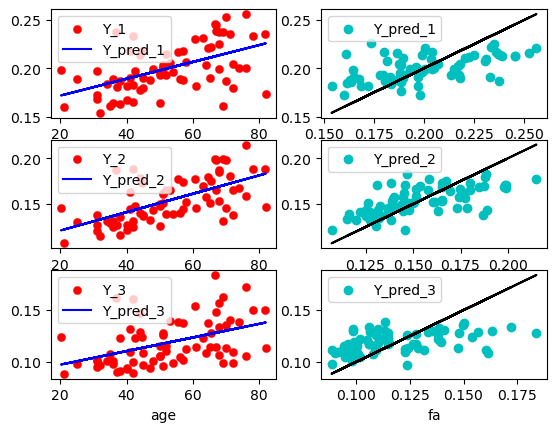

rh_precuneus
rh_rostralanteriorcingulate
rh_rostralmiddlefrontal
rh_superiorfrontal
rh_superiorparietal
Weights:
[[0.00078849]] [[0.00078586]] [[0.00044092]]
MSE:
0.0008633903336920572 0.0005475894217105514 0.0004096374563735899
R2:
0.143991548986945 0.20852149039709844 0.09980247993195146


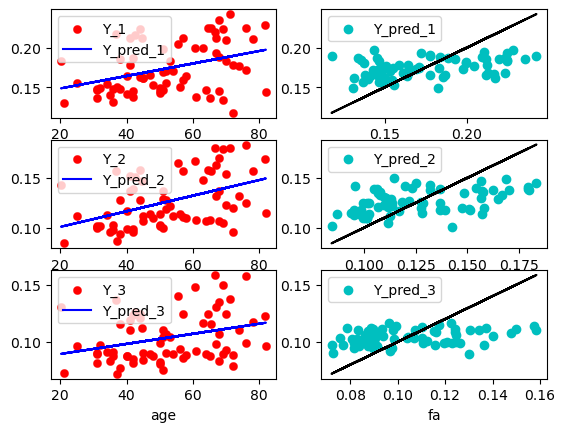

rh_superiortemporal
rh_supramarginal
rh_frontalpole
rh_temporalpole
rh_transversetemporal
rh_insula


In [33]:
# For left hemisphere
for region in region_list:
    print('rh_' + region)
    Y_1 = right_dic[region][:,0].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_1)
    r2_1 = linear_model.score(X, Y_1)
    weights_1 = linear_model.coef_
    Y_pred_1 = linear_model.predict(X)
    mse_1 = np.mean((Y_pred_1 - Y_1) ** 2)

    Y_2 = right_dic[region][:,1].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_2)
    r2_2 = linear_model.score(X, Y_2)
    weights_2 = linear_model.coef_
    Y_pred_2 = linear_model.predict(X)
    mse_2 = np.mean((Y_pred_2 - Y_2) ** 2)

    Y_3 = right_dic[region][:,2].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_3)
    r2_3 = linear_model.score(X, Y_3)
    weights_3 = linear_model.coef_
    Y_pred_3 = linear_model.predict(X)
    mse_3 = np.mean((Y_pred_3 - Y_3) ** 2)

    if r2_1 > 0.2 or r2_2 > 0.2 or r2_3 > 0.2:
        print('Weights:')
        print(weights_1, weights_2, weights_3)
        print('MSE:')
        print(mse_1, mse_2, mse_3)
        print('R2:')
        print(r2_1, r2_2, r2_3)
        plt.subplot(3, 2, 1)
        plt.scatter(X[:,0], Y_1[:,0], label='Y_1', color='r', linewidths=0.2)
        plt.plot(X[:,0], Y_pred_1[:,0], label='Y_pred_1', color='b')
        plt.legend()
        plt.xlabel('age')
        plt.subplot(3, 2, 2)
        plt.scatter(Y_1[:,0], Y_pred_1[:,0], label='Y_pred_1', color='c')
        plt.plot(Y_1[:,0], Y_1[:,0], color='k')
        plt.legend()
        plt.xlabel(type)
        plt.subplot(3, 2, 3)
        plt.scatter(X[:,0], Y_2[:,0], label='Y_2', color='r', linewidths=0.2)
        plt.plot(X[:,0], Y_pred_2[:,0], label='Y_pred_2', color='b')
        plt.legend()
        plt.xlabel('age')
        plt.subplot(3, 2, 4)
        plt.scatter(Y_2[:,0], Y_pred_2[:,0], label='Y_pred_2', color='c')
        plt.plot(Y_2[:,0], Y_2[:,0], color='k')
        plt.legend()
        plt.xlabel(type)
        plt.subplot(3, 2, 5)
        plt.scatter(X[:,0], Y_3[:,0], label='Y_3', color='r', linewidths=0.2)
        plt.plot(X[:,0], Y_pred_3[:,0], label='Y_pred_3', color='b')
        plt.legend()
        plt.xlabel('age')
        plt.subplot(3, 2, 6)
        plt.scatter(Y_3[:,0], Y_pred_3[:,0], label='Y_pred_3', color='c')
        plt.plot(Y_3[:,0], Y_3[:,0], color='k')
        plt.legend()
        plt.xlabel(type)
        plt.show()
